# Python Data Analysis 
# 2008 Crisis : South Asia - Economic Development 
## QTM 350: Final Project 
### Tina Piltner

## Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("../data/clean_wdi_data.csv")

print("Columns in dataset:")
print(df.columns.tolist())
df.head()

Columns in dataset:
['country_code', 'country_name', 'year', 'gdp_per_capita', 'gdp_growth_pct', 'employment_ratio', 'shock_period_flag']


,country_code,country_name,year,gdp_per_capita,gdp_growth_pct,employment_ratio,shock_period_flag
0,BGD,Bangladesh,1990,473.44,5.62,NaN,Normal
1,BGD,Bangladesh,1991,480.67,3.49,55.67,Normal
2,BGD,Bangladesh,1992,497.37,5.44,55.80,Normal
3,BGD,Bangladesh,1993,511.19,4.71,55.90,Normal
4,BGD,Bangladesh,1994,521.32,3.89,56.02,Normal


## 2008 Data

In [2]:
# years around the 2008 crisis
df_2008 = df[(df["year"] >= 2005) & (df["year"] <= 2012)].copy()

# Classify periods
def classify_period(year):
    if year in [2005, 2006, 2007]:
        return "Pre-crisis"
    elif year in [2008]:
        return "Crisis"
    elif year in [2009, 2010, 2011]:
        return "Post-crisis"
    return np.nan

df_2008["period"] = df_2008["year"].apply(classify_period)

print(df_2008.head())
print("\nYears included:", sorted(df_2008["year"].unique()))
print("Countries included:", sorted(df_2008["country_name"].unique()))

   country_code country_name  year  gdp_per_capita  gdp_growth_pct  \
15          BGD   Bangladesh  2005          739.20            6.54   
16          BGD   Bangladesh  2006          779.42            6.67   
17          BGD   Bangladesh  2007          825.51            7.06   
18          BGD   Bangladesh  2008          866.46            6.01   
19          BGD   Bangladesh  2009          901.73            5.05   

    employment_ratio      shock_period_flag       period  
15             55.65                 Normal   Pre-crisis  
16             55.99                 Normal   Pre-crisis  
17             55.86                 Normal   Pre-crisis  
18             55.70  2008 Financial Crisis       Crisis  
19             55.53                 Normal  Post-crisis  

Years included: [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)]
Countries included: ['Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pak

## Summary Stats

In [3]:
print("Overall Summary Statistics (2005–2012)")
overall_summary = df_2008[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]].describe().round(2)
print(overall_summary)

print("\n Summary Statistics by Country")
country_summary = (
    df_2008.groupby("country_name")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(country_summary)

print("\nSummary Statistics by Period ")
period_summary = (
    df_2008.groupby("period")[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(period_summary)

Overall Summary Statistics (2005–2012)
       gdp_per_capita  gdp_growth_pct  employment_ratio
count           56.00           56.00             56.00
mean          2501.85            5.86             51.31
std           2631.00            4.57              8.35
min            603.19          -11.18             36.37
25%            946.71            4.22             49.06
50%           1267.21            6.07             50.56
75%           2593.84            7.67             55.56
max           9396.50           23.63             67.36

 Summary Statistics by Country
             gdp_per_capita                                    gdp_growth_pct  \
                       mean   median     std      min      max           mean   
country_name                                                                    
Bangladesh           887.74   884.10  106.59   739.20  1050.39           6.24   
Bhutan              2129.71  2083.16  376.48  1632.02  2654.75           8.31   
India               

## Average values by country and period

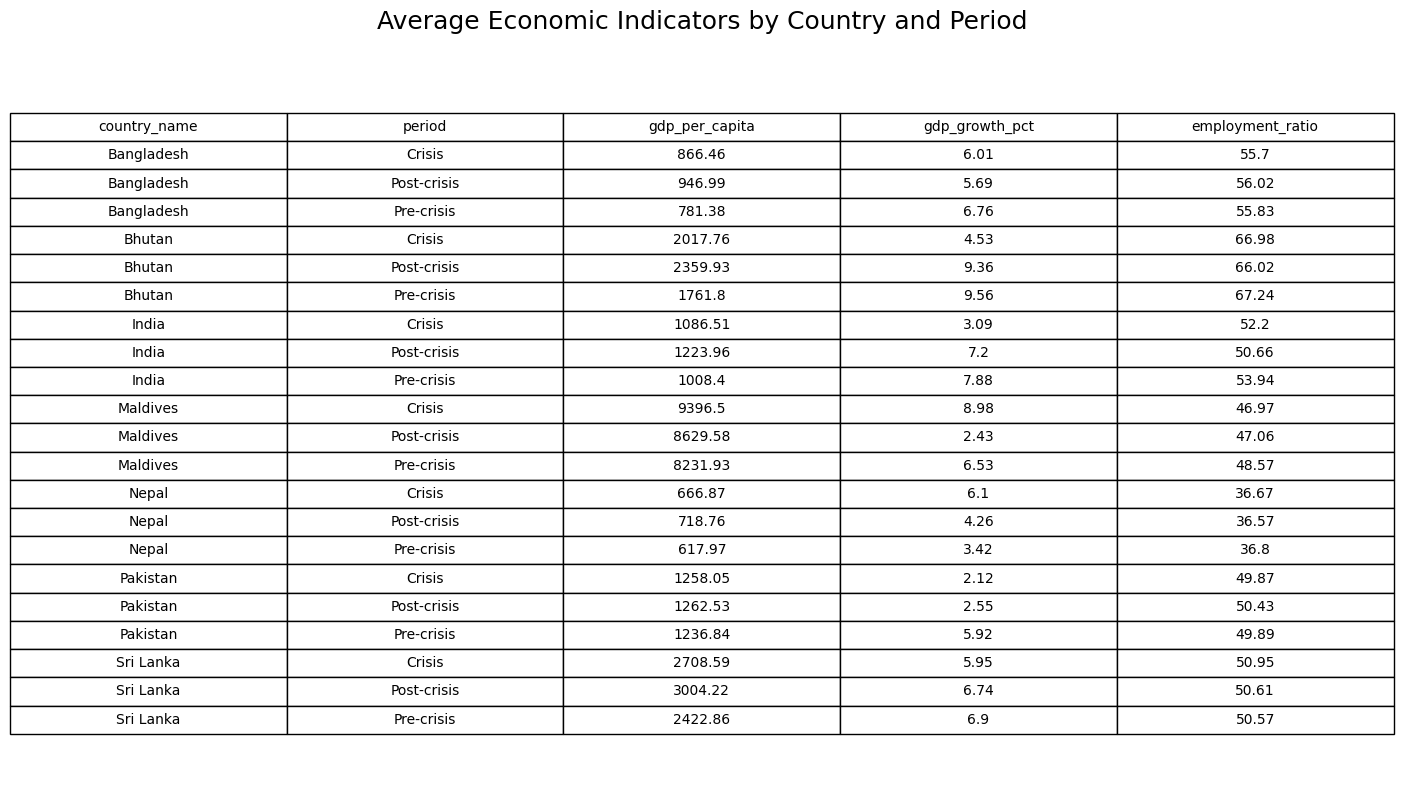

In [14]:
import matplotlib.pyplot as plt

country_period_avg = (
    df_2008.groupby(["country_name", "period"])[["gdp_per_capita", "gdp_growth_pct", "employment_ratio"]]
    .mean()
    .round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 9))  # make taller
ax.axis('off')

table = ax.table(
    cellText=country_period_avg.values,
    colLabels=country_period_avg.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

ax.set_title("Average Economic Indicators by Country and Period", fontsize=18, pad=20)

# saving table into figures folder
plt.tight_layout(rect=[0, 0, 1, 0.9]) 
plt.savefig("../figures/country_period_avg_table.png", dpi=300, bbox_inches='tight')
plt.show()

## GDP Growth 

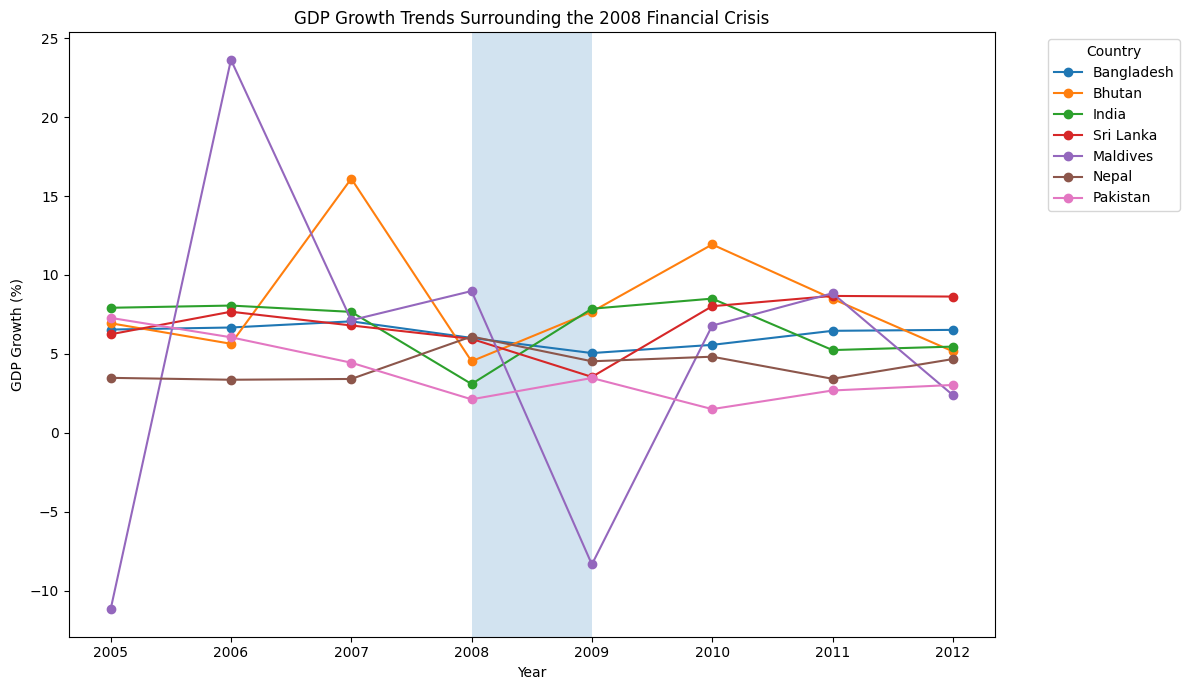

In [17]:
plt.figure(figsize=(12, 7))

for country in df_2008["country_name"].unique():
    country_data = df_2008[df_2008["country_name"] == country]
    plt.plot(
        country_data["year"],
        country_data["gdp_growth_pct"],
        marker="o",
        label=country
    )

plt.axvspan(2008, 2009, alpha=0.2)

plt.title("GDP Growth Trends Surrounding the 2008 Financial Crisis")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/gdp_growth_2008Crisis.png", dpi=300)
plt.show()

## Employment ratio

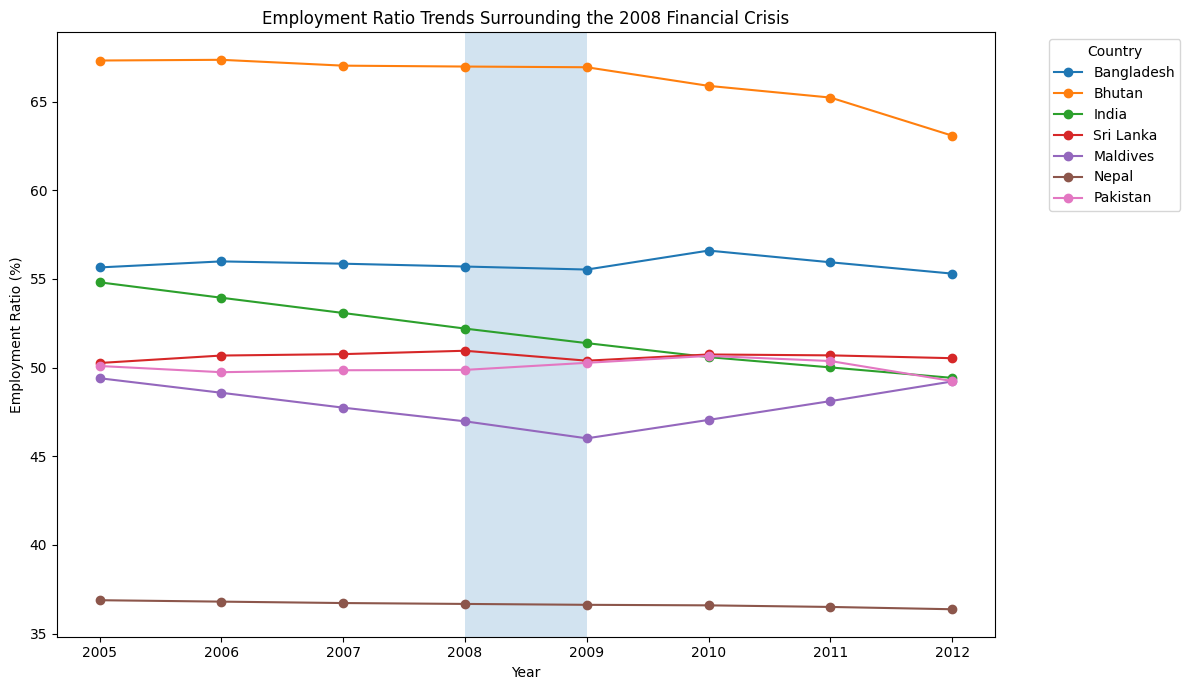

In [18]:
plt.figure(figsize=(12, 7))

for country in df_2008["country_name"].unique():
    country_data = df_2008[df_2008["country_name"] == country]
    plt.plot(country_data["year"], country_data["employment_ratio"], marker="o", label=country)

plt.axvspan(2008, 2009, alpha=0.2)

plt.title("Employment Ratio Trends Surrounding the 2008 Financial Crisis")
plt.xlabel("Year")
plt.ylabel("Employment Ratio (%)")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig("../figures/employment_ratio_2008Crisis.png", dpi=300)
plt.tight_layout()
plt.show()

## GDP per capita 

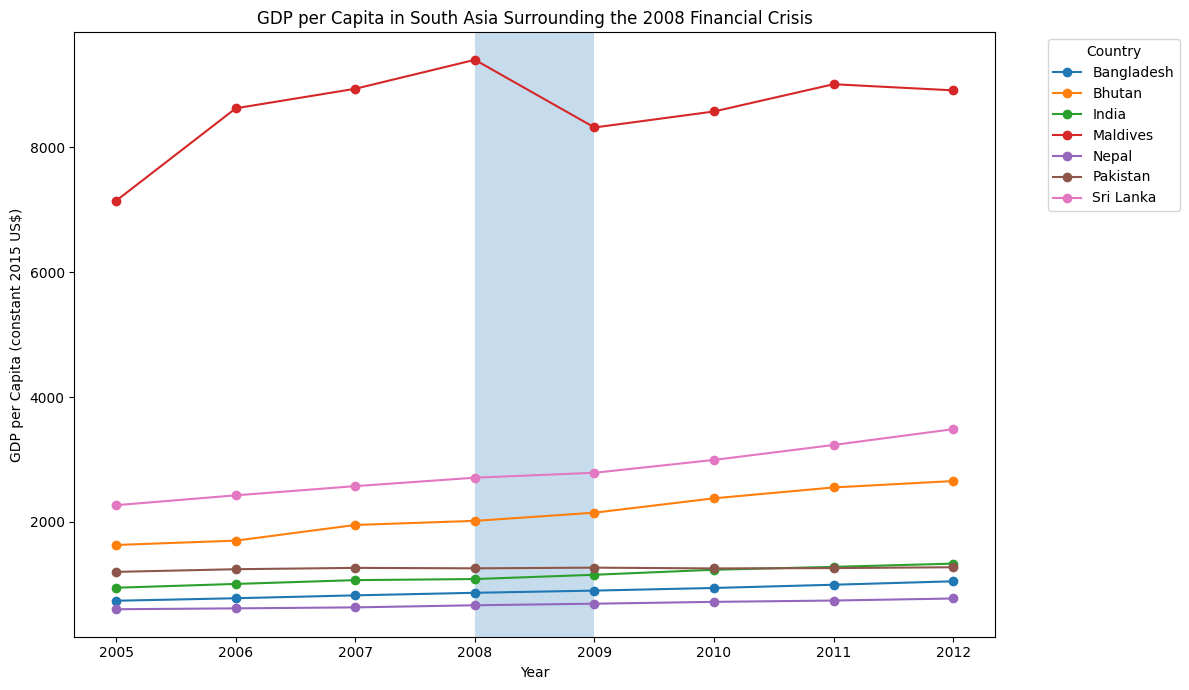

In [19]:
plt.figure(figsize=(12, 7))

for country in sorted(df_2008["country_name"].unique()):
    temp = df_2008[df_2008["country_name"] == country]
    plt.plot(temp["year"], temp["gdp_per_capita"], marker="o", label=country)

plt.axvspan(2008, 2009, alpha=0.25)

plt.title("GDP per Capita in South Asia Surrounding the 2008 Financial Crisis")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (constant 2015 US$)")
plt.xticks(sorted(df_2008["year"].unique()))
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/gdp_per_capita_2008Crisis.png", dpi=300)
plt.show()

## Average by period

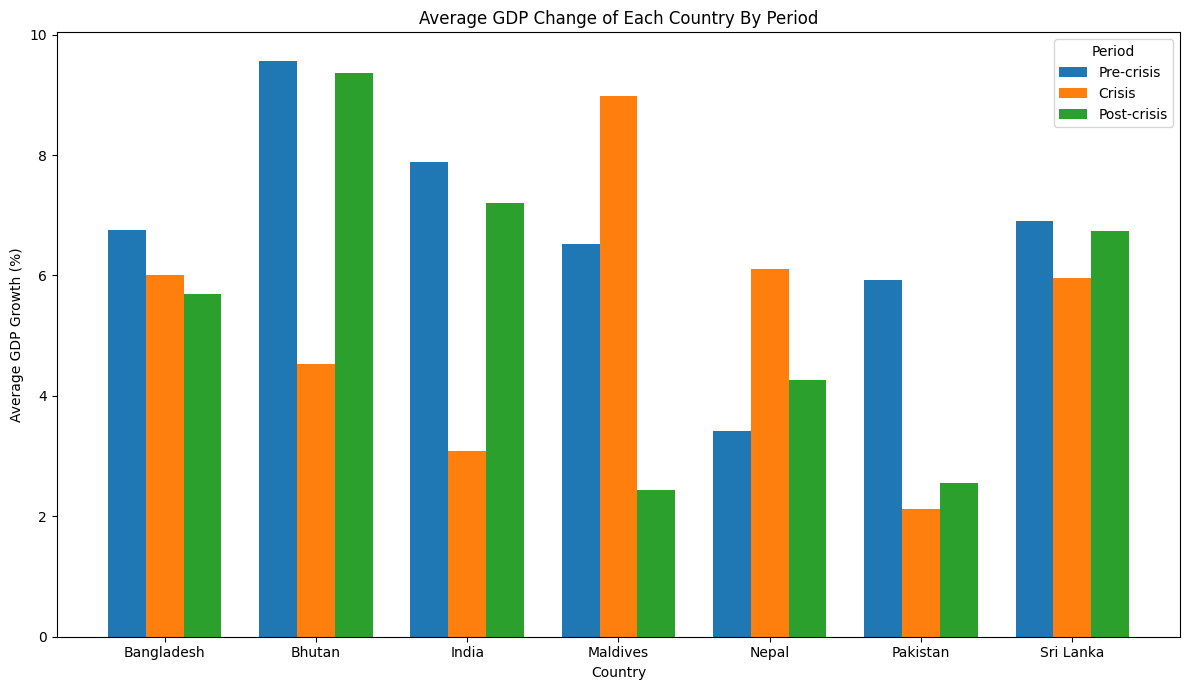

In [20]:
period_order = ["Pre-crisis", "Crisis", "Post-crisis"]

pivot_df = country_period_avg.pivot(
    index="country_name",
    columns="period",
    values="gdp_growth_pct"
)

pivot_df = pivot_df[period_order]

countries = pivot_df.index
x = np.arange(len(countries))
width = 0.25

plt.figure(figsize=(12, 7))

for i, period in enumerate(period_order):
    plt.bar(
        x + (i - 1) * width,
        pivot_df[period],
        width=width,
        label=period
    )

plt.xticks(x, countries)
plt.title("Average GDP Change of Each Country By Period")
plt.xlabel("Country")
plt.ylabel("Average GDP Growth (%)")
plt.legend(title="Period")
plt.tight_layout()
plt.savefig("../figures/gdp_bar_2008Crisis.png", dpi=300)
plt.show()